# TP 1 : la descente de gradient

Un problème dont on connaît la réponse exacte, pour pouvoir juger la descente au lieu de lui faire
confiance.

## 1.0 Un problème dont on connaît la réponse

442 patients diabétiques, dix mesures, et la progression de la maladie un an plus tard. Cette
fois les mesures sont dans leurs **unités d'origine** : l'âge en années (19 à 79), la tension
(62 à 133), le cholestérol total (97 à 301), et `s4` entre 2 et 9.

Le coût est la moyenne des carrés des erreurs,

$$J(w) = \frac{1}{m}\sum_{i=1}^{m}\big(w^T x^{(i)} - y^{(i)}\big)^2 ,$$

et il a une forme close, $w = (X^T X)^{-1}X^T y$. On s'en sert comme **réponse connue** : tout ce
que la descente produira sera comparé à elle.

**Q1.** La forme close $w = (X^T X)^{-1}X^T y$ ne se déduit que de ce coût-ci, la moyenne des
carrés. Des deux méthodes, la formule et la descente, laquelle vous restera-t-il quand le coût ne
sera plus celui-là ?

**Réponse attendue :** La descente. La formule ne vaut que pour ce coût-ci, celui de l'énoncé ; la descente, elle, ne
demande que de savoir dans quel sens le coût baisse, et cela se calcule pour n'importe quel coût.
Changez de coût et il ne vous reste qu'elle.

Ici la forme close sert d'**instrument de mesure** : elle donne la bonne réponse, donc elle permet
de dire si une descente est arrivée, ce qu'aucun problème réaliste ne permettra. C'est la raison
d'être de ce TP.

Attention, la descente n'est pas une approximation de la formule, un repli moins bon employé quand
la formule manque. C'est l'inverse : la formule est le cas particulier, la descente le cas général.
Et « exacte » ne suffit pas à trancher ; la formule est bien exacte, mais dès que le coût change,
elle n'existe plus.

*Pour aller plus loin :* deux raisons s'ajoutent, même quand la forme close existe. Elle demande de
former et de résoudre un système $(n+1) \times (n+1)$, ce qui devient coûteux quand $n$ est grand,
et elle exige de tenir toutes les données à la fois, alors qu'une descente peut consommer les
exemples par paquets. Et dès que l'activation n'est plus l'identité (une sigmoïde, une softmax,
une couche cachée), le gradient n'est plus linéaire en $w$ et il n'y a plus de système à résoudre.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

np.seterr(all="ignore")          # an exploding descent overflows; the numbers still tell the story
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

data = load_diabetes(as_frame=True, scaled=False)
feature_names = list(data.data.columns)
X, y = data.data.values, data.target.values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


def design_matrix(X):
    return np.hstack([np.ones((len(X), 1)), X])


def cost(X, y, w):
    return np.mean((design_matrix(X) @ w - y) ** 2)


w_star = np.linalg.lstsq(design_matrix(X_train), y_train, rcond=None)[0]
print(f"coût minimal, par la forme close : {cost(X_train, y_train, w_star):.2f}")
print()
print(data.data.describe().loc[["min", "max", "std"]].round(1).to_string())

coût minimal, par la forme close : 2734.75

      age  sex   bmi     bp     s1     s2    s3   s4   s5     s6
min  19.0  1.0  18.0   62.0   97.0   41.6  22.0  2.0  3.3   58.0
max  79.0  2.0  42.2  133.0  301.0  242.4  99.0  9.1  6.1  124.0
std  13.1  0.5   4.4   13.8   34.6   30.4  12.9  1.3  0.5   11.5


## 1.1 Le gradient, à la main

La descente part d'un $w$ quelconque et le corrige dans la direction qui fait baisser le coût :

$$\boxed{\ w \leftarrow w - \alpha \nabla_w J(w), \qquad
  \nabla_w J(w) = \frac{2}{m} X^T (Xw - y)\ }$$

Le gradient s'écrit en une ligne de numpy, mais une erreur de signe ou de facteur ne se voit pas :
la descente marche encore, en plus lent ou en divergeant. On l'écrit donc **deux fois** : une fois
sous sa forme matricielle, une fois comme la moyenne sur les $m$ patients dont elle est le
raccourci,

$$\frac{\partial J}{\partial w_j} = \frac{2}{m}\sum_{i=1}^{m}
  \big(w^T x^{(i)} - y^{(i)}\big)\, x_j^{(i)},$$

et on vérifie que les deux coïncident. Un facteur ou un signe oublié d'un seul côté se voit
aussitôt.

**Q2.** Dans le tableau des écarts-types affiché plus haut, `s1` vaut 34,6 et `s5` vaut 0,5 : les
valeurs de `s1` sont environ soixante-dix fois plus grandes. Le gradient multiplie chaque erreur par
la valeur de la colonne : laquelle des deux reçoit la plus grande composante de gradient ?
Qu'en concluez-vous pour un $\alpha$ unique appliqué aux deux ?

**Réponse attendue :** `s1`. La coordonnée du gradient associée à une colonne est une somme des erreurs multipliées par
les valeurs de cette colonne : elle est donc proportionnelle à l'échelle de cette colonne. Avec un
écart-type de 34,6 contre 0,5, `s1` reçoit une composante de gradient environ soixante-dix fois
plus grande que `s5`.

La conséquence tombe sur $\alpha$, qui est un **scalaire unique** appliqué à toutes les
coordonnées. Un pas assez petit pour ne pas faire exploser le poids de `s1` sera environ
soixante-dix fois trop petit pour celui de `s5` : pendant que l'un se règle, l'autre rampe. C'est
le problème que la section 1.2 va rencontrer de plein fouet.

Attention, une grande composante de gradient ne veut pas dire que `s1` compte plus : elle ne dit
rien de l'importance de la colonne, seulement de ses unités, et si vous mesurez `s1` autrement le
chiffre change. Attention aussi au réflexe de prendre un $\alpha$ plus petit : il sauve la
stabilité et aggrave la lenteur, ce qui est exactement l'impasse de la section suivante.

*Pour aller plus loin :* l'écriture exacte de la coordonnée $j$ est
$\frac{2}{m}\sum_i (w^T x^{(i)} - y^{(i)})\, x_j^{(i)}$. L'échelle de la colonne intervient au
carré dans $X^T X$ : la courbure du coût dans cette direction (sa sensibilité à ce poids) grandit
comme le carré du rapport des échelles, et c'est la section 1.3 qui la chiffre.

In [2]:
def gradient(X, y, w):
    A = design_matrix(X)
    return 2 * A.T @ (A @ w - y) / len(y)


def gradient_per_patient(X, y, w):
    """The same gradient, written as the mean over the m patients."""
    A = design_matrix(X)
    errors = A @ w - y
    return np.mean(2 * errors[:, None] * A, axis=0)


w_probe = np.full(X_train.shape[1] + 1, 0.5)
assert np.allclose(gradient(X_train, y_train, w_probe),
                   gradient_per_patient(X_train, y_train, w_probe))
assert np.allclose(gradient(X_train, y_train, w_star), 0.0, atol=1e-6)

print("les deux écritures du gradient coïncident")
print(f"norme du gradient au minimum : {np.linalg.norm(gradient(X_train, y_train, w_star)):.2e}")
print(f"norme du gradient en w = 0   : {np.linalg.norm(gradient(X_train, y_train, np.zeros(11))):.2e}")

les deux écritures du gradient coïncident
norme du gradient au minimum : 3.66e-10
norme du gradient en w = 0   : 8.28e+04


**Q3.** La norme du gradient affichée passe de $8{,}28 \times 10^4$ en $w = 0$ à
$3{,}66 \times 10^{-10}$ au minimum. Quel test d'arrêt ces deux nombres suggèrent-ils pour la
descente ?

**Réponse attendue :** On peut s'arrêter sur $\lVert \nabla J \rVert < \varepsilon$. C'est la seule quantité qui dise
quelque chose sur *où l'on est* : elle vaut zéro au minimum et rien d'autre. Les deux nombres
affichés le montrent : $8{,}28 \times 10^4$ en $w = 0$, $3{,}66 \times 10^{-10}$ au minimum. Un
seuil placé entre les deux, loin de l'un comme de l'autre, sépare sans ambiguïté « on rampe
encore » de « on est arrivé ».

Ce seuil se choisit, il ne se décrète pas : $\varepsilon$ n'a pas de valeur universelle, il hérite
des unités du coût et des données, et se règle en regard de ces deux ordres de grandeur. Le seuil
de 0,01 retenu en 1.4 est minuscule devant $8{,}28 \times 10^4$ et énorme devant
$3{,}66 \times 10^{-10}$ : il demande d'être arrivé, sans exiger la précision de la forme close.

Deux autres arrêts viennent à l'esprit et valent moins que celui-là. « Au bout d'un nombre de pas
fixé d'avance » ne mesure rien, et la section 1.4 ne le garde que comme garde-fou. Et « quand le
coût ne baisse plus beaucoup » dépend autant du pas choisi que de l'endroit où l'on est : la
question Q8 y revient, sortie à l'appui.

## 1.2 Chercher un pas qui marche

Un $\alpha$ trop petit met des siècles à arriver ; un $\alpha$ trop grand fait remonter le coût à
chaque pas et diverge. On balaie donc plusieurs ordres de grandeur, sur les mesures **en unités
d'origine**.

**Q4.** Le balayage qui suit essaie six valeurs de $\alpha$ sur les mesures en unités d'origine,
avec un seul $\alpha$ pour tous les poids, alors que `s1` va de 97 à 301 et `s4` de 2 à 9,1. Deux
issues possibles : l'une de ces valeurs atteint le minimum, ou bien chacune diverge ou avance trop
lentement pour y arriver. Laquelle attendez-vous ?

**Réponse attendue :** Aucune des six n'atteint le minimum. Les colonnes n'ont pas les mêmes unités (`s1` va de 97 à 301,
`s4` de 2 à 9,1) et un seul $\alpha$ doit convenir aux deux. Assez petit pour ne pas faire exploser
les poids des grandes colonnes, il n'avance presque pas sur les petites ; assez grand pour les
petites, il fait diverger les grandes.

C'est un fait sur les **unités des colonnes**, pas sur le réglage : aucun balayage de $\alpha$,
aussi fin soit-il, ne le contourne. La section 1.3 s'en prend aux unités elles-mêmes.

Attention, « il suffit d'essayer assez de valeurs » est le réflexe du réglage, et il échoue ici :
il n'y a pas de bonne valeur à trouver. Attention aussi à la conclusion inverse, qui vient en
lisant le tableau : ce n'est pas la descente qui est une mauvaise méthode.

minimum atteignable : 2734.75
      α coût après 2 000 pas excès sur le minimum  diverge
1.0e-07               5375.6               2640.8    False
1.0e-06               4129.8               1395.1    False
5.0e-06               3384.7                650.0    False
1.0e-05               3192.4                457.6    False
1.3e-05               3138.7                404.0    False
2.0e-05                  inf                  inf     True


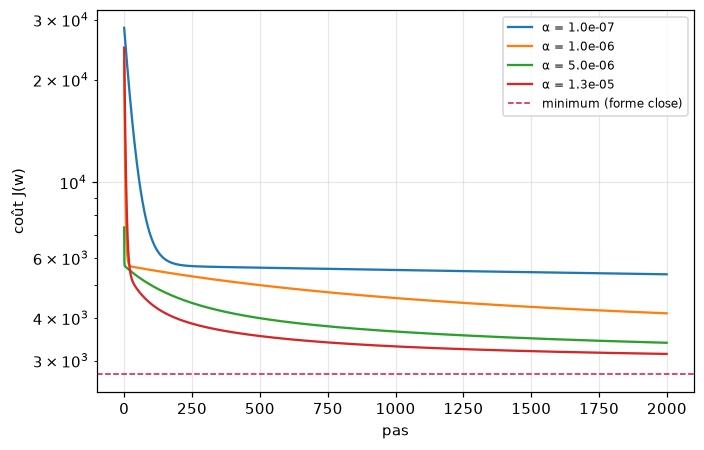

In [3]:
def descend(X, y, alpha, n_steps):
    """Batch gradient descent from w = 0. Returns the weights and the cost after each step."""
    w = np.zeros(X.shape[1] + 1)
    history = []
    for _ in range(n_steps):
        w = w - alpha * gradient(X, y, w)
        history.append(cost(X, y, w))
        if not np.isfinite(w).all():
            break
    return w, np.array(history)


minimum = cost(X_train, y_train, w_star)
rows = []
for alpha in (1e-7, 1e-6, 5e-6, 1e-5, 1.3e-5, 2e-5):
    w_alpha, history = descend(X_train, y_train, alpha, 2000)
    rows.append({"α": alpha, "coût après 2 000 pas": history[-1],
                 "excès sur le minimum": history[-1] - minimum,
                 "diverge": not np.isfinite(history[-1])})

assert len(rows) == 6
print(f"minimum atteignable : {minimum:.2f}")
print(pd.DataFrame(rows).to_string(index=False, formatters={
    "α": "{:.1e}".format, "coût après 2 000 pas": "{:.1f}".format,
    "excès sur le minimum": "{:.1f}".format}))

fig, ax = plt.subplots(figsize=(7, 4.5))
for alpha in (1e-7, 1e-6, 5e-6, 1.3e-5):
    _, history = descend(X_train, y_train, alpha, 2000)
    ax.plot(history, label=f"α = {alpha:.1e}")
ax.axhline(minimum, color="crimson", ls="--", lw=1, label="minimum (forme close)")
ax.set_yscale("log")
ax.set_xlabel("pas")
ax.set_ylabel("coût J(w)")
ax.legend(fontsize=8)
plt.show()

**Q5.** Dans le tableau, $\alpha = 1{,}3 \times 10^{-5}$ laisse encore 404 d'excès sur le minimum
après deux mille pas, et l'$\alpha$ juste au-dessus, $2 \times 10^{-5}$, diverge. Entre « trop lent »
et « diverge » il n'y a donc rien à régler : qu'est-ce qui bloque, l'algorithme de descente ou les
unités des colonnes ?

**Réponse attendue :** Les unités. Entre les 404 d'excès que laisse $\alpha = 1{,}3 \times 10^{-5}$ après deux mille pas
et l'`inf` de la ligne suivante, la fenêtre entre « diverge » et « inutilisablement lent » est
vide : il n'y a pas de réglage à trouver.

Ce n'est pourtant pas le problème qui résiste, et l'algorithme n'est pas en cause : le gradient a
été écrit deux fois et vérifié en 1.1, le coût est une moyenne de carrés, son minimum est unique et
connu, 2 734,75. Ce qui bloque, c'est qu'une colonne a un écart-type de 34,6 et une autre de 0,5,
alors qu'un seul $\alpha$ doit convenir aux deux. La section suivante change les unités, pas
l'algorithme, et le même code arrive en huit pas.

Attention, ne concluez pas que « la descente de gradient ne marche pas sur ce problème » : la même
descente, ligne pour ligne, atteindra 2 734,75 en 1.3. L'erreur symétrique consiste à lire la ligne
$1{,}3 \times 10^{-5}$ comme un succès : 3 138,7 contre 2 734,75, on est encore loin, et la colonne
« excès sur le minimum » est là pour l'empêcher.

## 1.3 Mettre les colonnes à la même échelle

Ce qui bloque n'est pas la descente, ce sont les **unités**. Un seul $\alpha$ s'applique à tous les
poids, alors que les colonnes vont de 0,5 d'écart-type pour `s5` à 34,6 pour `s1` : le pas qui
convient à l'une est soixante-dix fois trop grand ou trop petit pour l'autre.

La correction est d'enlever le problème plutôt que de régler autour : on ramène chaque colonne à une
moyenne nulle et un écart-type de 1. Les statistiques se calculent **sur l'entraînement seul**, puis
s'appliquent au test : une moyenne calculée sur le test ferait entrer le test dans le modèle.

Le modèle, lui, ne change pas : le minimum du coût reste le même, seule la route pour y arriver
change de forme. L'`assert` de la cellule le vérifie.

**Q6.** Après standardisation, toutes les colonnes auront le même écart-type. Un même $\alpha$
conviendra-t-il alors à tous les poids ?

**Réponse attendue :** Oui. C'est même tout l'intérêt de l'opération : tant que les colonnes ont des écarts-types allant de
0,5 à 34,6, le pas qui convient à l'une ne convient pas à l'autre, et un seul $\alpha$ doit pourtant
servir aux onze poids. Une fois toutes les colonnes à un écart-type de 1, elles réclament des pas du
même ordre, et un $\alpha$ unique redevient un réglage raisonnable.

La sortie le montre en deux lignes : les écarts-types passent de « 0,5 à 34,2 » à « 1 à 1 ». Et le
tableau qui suit donne le résultat : 8 pas à $\alpha = 0{,}2$, là où aucune des six valeurs en
unités d'origine n'arrivait.

Attention, standardiser ne change pas de modèle. Le coût minimal est le même des deux côtés,
l'`assert` sur la forme close le vérifie ; seule la route vers ce minimum change de forme. Regardez
aussi le code sur ce point : la moyenne et l'écart-type se calculent sur l'entraînement seul, car
recentrer le test sur lui-même utiliserait des données qu'on n'est pas censé voir.

*Pour aller plus loin :* la forme close, elle, n'a pas besoin qu'on standardise. Elle résout le
système exactement, sans pas ni itération, et un changement d'échelle d'une colonne se répercute
simplement sur le coefficient correspondant. Standardiser est un besoin de la **descente**, pas du
modèle.

In [4]:
mean, deviation = X_train.mean(axis=0), X_train.std(axis=0)
Z_train = (X_train - mean) / deviation
Z_test = (X_test - mean) / deviation

assert np.allclose(Z_train.mean(axis=0), 0.0)
assert np.allclose(Z_train.std(axis=0), 1.0)
assert not np.allclose(Z_test.mean(axis=0), 0.0)     # the test set is not recentred on itself

for name, M in (("unités d'origine", X_train), ("standardisé", Z_train)):
    print(f"{name:<18} écarts-types des colonnes : "
          f"de {M.std(axis=0).min():.3g} à {M.std(axis=0).max():.3g}")

w_star_z = np.linalg.lstsq(design_matrix(Z_train), y_train, rcond=None)[0]
assert np.isclose(cost(Z_train, y_train, w_star_z), cost(X_train, y_train, w_star))

rows = []
for alpha in (0.001, 0.01, 0.05, 0.1, 0.2, 0.24, 0.3):
    _, history = descend(Z_train, y_train, alpha, 2000)
    reached = np.flatnonzero(history < 1.01 * minimum)
    rows.append({"α": alpha, "coût après 2 000 pas": history[-1],
                 "pas pour arriver à 1 % du minimum": reached[0] + 1 if len(reached) else None})
print()
print(pd.DataFrame(rows).to_string(index=False, formatters={"coût après 2 000 pas": "{:.1f}".format}))

unités d'origine   écarts-types des colonnes : de 0.5 à 34.2
standardisé        écarts-types des colonnes : de 1 à 1



    α coût après 2 000 pas  pas pour arriver à 1 % du minimum
0.001               2759.8                             1943.0
0.010               2742.4                              193.0
0.050               2735.1                               38.0
0.100               2734.8                               18.0
0.200               2734.8                                8.0
0.240               2734.8                              203.0
0.300                  NaN                                NaN


**Q7.** Dans la colonne `pas pour arriver à 1 % du minimum`, $\alpha = 0{,}2$ met 8 pas,
$\alpha = 0{,}24$ en met 203, et $\alpha = 0{,}3$ diverge. Que retenez-vous sur le choix d'un $\alpha$
juste en dessous de celui qui diverge ?

**Réponse attendue :** Qu'il ne faut pas le prendre juste en dessous. Le plus grand $\alpha$ qui ne diverge pas n'est pas
le plus rapide : à 0,2 la descente arrive en 8 pas, à 0,24 il lui en faut 203, et à 0,3 elle ne
converge plus. Le nombre de pas ne décroît donc pas jusqu'au point de divergence, il remonte avant.

En pratique on se tient franchement en dessous. Ici 0,05, 0,1 et 0,2 demandent 38, 18 et 8 pas :
tout ce voisinage marche, et la dégradation n'apparaît qu'en approchant 0,24.

Attention, « prendre $\alpha$ aussi grand que possible » mène exactement à la ligne 0,24. Et il n'y
a pas seulement deux régimes, trop lent et divergent : il en existe un troisième entre les deux,
stable et lent pour rien.

*Pour aller plus loin :* voici le mécanisme. Dans la direction où le coût est le plus raide, un
$\alpha$ trop proche de la limite fait sur-corriger la descente : à chaque pas elle saute de l'autre
côté du fond de la vallée, à peine plus près qu'avant. Cette composante oscille en changeant de
signe au lieu de décroître, d'où les 203 pas.

## 1.4 Ce que veut dire « jusqu'à convergence »

On s'arrête quand la norme du gradient passe sous un seuil $\varepsilon$, et un **plafond
d'itérations** sert de garde-fou : sans lui, un $\alpha$ mal réglé tourne indéfiniment.

**Q8.** Deux arrêts possibles : « le gradient est devenu petit » et « le coût ne baisse plus
beaucoup ». Lequel des deux un $\alpha$ minuscule trompe-t-il ?

**Réponse attendue :** Celui du coût. Un $\alpha$ minuscule fait des pas minuscules, donc des baisses de coût minuscules :
le critère « le coût ne baisse plus beaucoup » est satisfait immédiatement, alors qu'on est encore
très loin. Le gradient, lui, ne se laisse pas tromper : il reste grand tant qu'on n'est pas arrivé,
puisqu'il ne dépend pas du pas qu'on prend.

Le critère du gradient a son propre défaut, mais de l'autre côté : il peut ne jamais être
satisfait, d'où le plafond d'itérations.

In [5]:
def descend_until(X, y, alpha, epsilon=1e-2, max_steps=100000):
    w = np.zeros(X.shape[1] + 1)
    for step in range(1, max_steps + 1):
        g = gradient(X, y, w)
        if np.linalg.norm(g) < epsilon:
            return w, step, "gradient"
        w = w - alpha * g
    return w, max_steps, "plafond"


rows = []
for alpha in (1e-5, 0.001, 0.05, 0.2):
    M = X_train if alpha == 1e-5 else Z_train
    w_end, steps, reason = descend_until(M, y_train, alpha)
    rows.append({"données": "origine" if alpha == 1e-5 else "standardisé", "α": alpha,
                 "arrêt": reason, "pas": steps, "coût atteint": cost(M, y_train, w_end),
                 "‖∇J‖ à l'arrêt": np.linalg.norm(gradient(M, y_train, w_end))})

assert rows[0]["arrêt"] == "plafond"
assert rows[-1]["arrêt"] == "gradient"
print(f"minimum : {minimum:.2f}")
print(pd.DataFrame(rows).to_string(index=False, formatters={
    "coût atteint": "{:.2f}".format, "‖∇J‖ à l'arrêt": "{:.3g}".format}))

minimum : 2734.75
    données       α    arrêt    pas coût atteint ‖∇J‖ à l'arrêt
    origine 0.00001  plafond 100000      2939.56           7.36
standardisé 0.00100  plafond 100000      2735.13          0.119
standardisé 0.05000 gradient   4639      2734.75           0.01
standardisé 0.20000 gradient   1159      2734.75        0.00999


**Q9.** La ligne `origine` s'est arrêtée après 100 000 pas sur un coût de 2 939,56, pour un minimum à
2 734,75. Quelle colonne du tableau permet de voir qu'elle n'a pas convergé, et pourquoi la fonction
doit-elle rendre cette information avec le modèle ?

**Réponse attendue :** La colonne « arrêt » : elle affiche `plafond`, c'est-à-dire que la boucle s'est arrêtée parce que
le budget d'itérations était épuisé, et non parce que le gradient était devenu petit. La colonne
`‖∇J‖ à l'arrêt` confirme, 7,36 quand le seuil est à 0,01. Les 2 939,56 atteints ne sont pas le
meilleur modèle linéaire sur ces données, c'est l'endroit où le budget s'est épuisé.

La fonction doit rendre cette information parce que, sans elle, les deux cas (arrivé, ou
interrompu) se présentent exactement de la même façon : un $w$ et un coût. On livrerait un modèle
non convergé sans aucun moyen de s'en apercevoir. Rendre la raison de l'arrêt avec le modèle est le
réflexe à garder.

La ligne standardisée à $\alpha = 0{,}001$ le montre par l'autre bout : elle atteint aussi le
plafond, avec un coût de 2 735,13 pourtant excellent. « Plafond atteint » ne veut donc pas dire
« mauvais modèle », mais « on ne sait pas ». Attention, la colonne du coût mérite d'être regardée,
mais elle ne suffit pas : 2 735,13 ressemble à une convergence réussie, et 2 939,56 ne se juge que
parce qu'on connaît le minimum.

*Pour aller plus loin :* le diagnostic est facile ici parce que la forme close donne le minimum
exact. Sur un problème sans forme close, on n'a pas ce point de comparaison : d'où le poids des
critères d'arrêt, du plafond, et de plusieurs départs pour se convaincre qu'on arrive au même
endroit.

## 1.5 Par lots, par mini-lots, ou un patient à la fois

Le gradient est une somme sur les $m$ patients. Trois façons de la consommer :

| | Exemples par pas | Mises à jour par époque |
|---|---|---|
| **par lots** | les $m$ | 1 |
| **mini-lots** | $b$ | $m / b$ |
| **stochastique** | 1 | $m$ |

Une **époque** est un passage complet sur les $m$ exemples : à budget d'époques égal, les trois
méthodes ne font donc pas le même nombre de mises à jour.

**Q10.** Le tableau donne les mises à jour par époque : 1 par lots, $m/b$ en mini-lots, $m$ en
stochastique. À $\alpha$ égal et à nombre d'époques égal, laquelle des trois avance le plus vite ?
Qu'en concluez-vous sur l'époque comme unité de comparaison ?

**Réponse attendue :** La stochastique. À $\alpha$ égal, une époque lui donne $m$ mises à jour là où la descente par lots
n'en fait qu'une et les mini-lots $m/b$ : le classement est 1 contre $m/b$ contre $m$, dans cet
ordre.

Donc l'époque n'est pas une unité de comparaison honnête : elle compte les passages sur les données,
c'est-à-dire le calcul dépensé, pas l'avancement. La sortie suivante le montre : pour cinquante
époques, 50 mises à jour par lots, 600 en mini-lots de 32, 17 650 en stochastique. Comparer les
trois « à cinquante époques » compare trois budgets de mises à jour très différents, d'où la figure
tracée en fonction des mises à jour.

Attention à la conclusion hâtive : « avance le plus vite » se lit ici par mise à jour, pas en temps
de calcul. Une mise à jour stochastique lit un patient, une mise à jour par lots en lit 353, donc à
calcul égal l'écart se resserre beaucoup. Attention aussi à « par lots, puisque son gradient est
exact » : cela confond la qualité de la direction et le nombre de pas faits.

*Pour aller plus loin :* la plus propre en fin de course est la descente **par lots** : son gradient
est exact, donc avec assez de mises à jour elle s'arrête vraiment au minimum, alors que les deux
autres n'en voient qu'une estimation bruitée et continuent de sautiller autour. La sortie ne le
montre pas telle quelle : la colonne `oscillation en fin de course` affiche 452,6 par lots contre
22,6 en stochastique, mais avec 50 mises à jour la descente par lots est encore en pleine chute
(coût final 5 996,0), et la colonne mesure alors sa descente, pas du bruit. C'est la comparaison de
Q11, à nombre de mises à jour égal, qui chiffre le bruit.

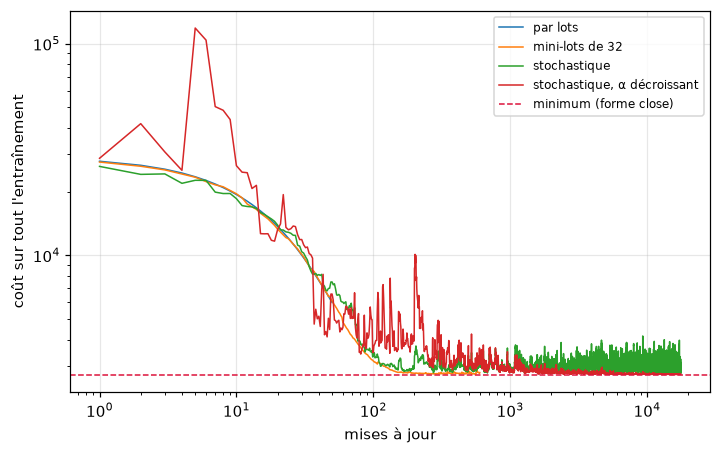

minimum : 2734.75   (50 époques, α = 0.01 sauf mention)
                    méthode  exemples par pas  mises à jour coût final oscillation en fin de course
                   par lots               353            50     5996.0                        452.6
            mini-lots de 32                32           600     2793.5                          4.7
               stochastique                 1         17650     2958.5                         22.6
stochastique, α décroissant                 1         17650     2738.3                          0.3


In [6]:
def descend_batches(X, y, alpha, batch_size, n_epochs, decay=None, seed=0):
    """One pass per epoch, in shuffled batches. `decay`: alpha / (1 + updates / decay)."""
    rng = np.random.default_rng(seed)
    w = np.zeros(X.shape[1] + 1)
    history, updates = [], 0
    for _ in range(n_epochs):
        order = rng.permutation(len(X))
        for start in range(0, len(X), batch_size):
            rows = order[start:start + batch_size]
            step = alpha if decay is None else alpha / (1 + updates / decay)
            w = w - step * gradient(X[rows], y[rows], w)
            updates += 1
            history.append((updates, cost(X, y, w)))
    return w, np.array(history)


alpha = 0.01
settings = [("par lots", len(Z_train)), ("mini-lots de 32", 32), ("stochastique", 1)]
fig, ax = plt.subplots(figsize=(7.5, 4.5))
rows = []
for label, batch_size in settings:
    w_end, history = descend_batches(Z_train, y_train, alpha, batch_size, 50)
    ax.plot(history[:, 0], history[:, 1], label=label, lw=1)
    tail = history[-10:, 1]
    rows.append({"méthode": label, "exemples par pas": batch_size,
                 "mises à jour": int(history[-1, 0]), "coût final": history[-1, 1],
                 "oscillation en fin de course": tail.std()})

assert rows[0]["mises à jour"] == 50
assert rows[2]["mises à jour"] == 50 * len(Z_train)

w_decay, history_decay = descend_batches(Z_train, y_train, 0.05, 1, 50, decay=200)
ax.plot(history_decay[:, 0], history_decay[:, 1], label="stochastique, α décroissant", lw=1)
rows.append({"méthode": "stochastique, α décroissant", "exemples par pas": 1,
             "mises à jour": int(history_decay[-1, 0]), "coût final": history_decay[-1, 1],
             "oscillation en fin de course": history_decay[-10:, 1].std()})

ax.axhline(minimum, color="crimson", ls="--", lw=1, label="minimum (forme close)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("mises à jour")
ax.set_ylabel("coût sur tout l'entraînement")
ax.legend(fontsize=8)
plt.show()

print(f"minimum : {minimum:.2f}   (50 époques, α = {alpha} sauf mention)")
print(pd.DataFrame(rows).to_string(index=False, formatters={
    "coût final": "{:.1f}".format, "oscillation en fin de course": "{:.1f}".format}))

**Q11.** Les deux dernières lignes du tableau font le même nombre de mises à jour, 17 650, mais
l'`oscillation en fin de course` passe de 22,6 à 0,3 et le `coût final` de 2 958,5 à 2 738,3 quand
$\alpha$ décroît. Qu'apporte donc un $\alpha$ décroissant à la descente stochastique ?

**Réponse attendue :** Il éteint le bruit résiduel. On garde de grands pas pour arriver, puis des pas de plus en plus
petits, qui ne rejettent plus loin du minimum une fois qu'on y est. Sur la sortie, à nombre de
mises à jour identique (17 650 des deux côtés), l'oscillation en fin de course tombe de 22,6 à 0,3
et le coût final de 2 958,5 à 2 738,3, pour un minimum à 2 734,75.

Ce qui manquait à la descente stochastique n'était donc pas la vitesse mais la capacité à se poser.
Avec 17 650 mises à jour, elle était passée près du minimum depuis longtemps ; elle en repartait à
chaque exemple, parce qu'un seul patient donne une direction juste en moyenne seulement. Un
$\alpha$ décroissant ne l'accélère pas, il l'empêche de repartir.

Deux réserves. La ligne décroissante part d'un $\alpha$ plus grand, la sortie le signale par « sauf
mention » : ce n'est donc pas une comparaison toutes choses égales, seul le nombre de mises à jour
l'est. Et attention, « ça converge plus vite » se trompe de grandeur : il n'y a pas un pas de moins,
il y a une fin de course propre.

*Pour aller plus loin :* la condition classique est que $\alpha_t$ décroisse assez lentement pour
que $\sum_t \alpha_t$ diverge (sinon les pas s'épuisent avant l'arrivée), mais assez vite pour que
$\sum_t \alpha_t^2$ converge, sinon le bruit ne s'éteint jamais ; la forme
$\alpha_0/(1 + t/\tau)$ du code satisfait les deux. Retenez aussi de la même sortie que les
mini-lots de 32 atteignent 2 793,5 en 600 mises à jour, ce qui est le compromis retenu en pratique.

**Q12.** Le coût de ce TP est **convexe** : une seule vallée, donc tout point où le gradient
s'annule est le minimum. Lequel de ces deux énoncés la convexité garantit-elle : « la descente
arrive au minimum », ou « si la descente arrive, c'est au minimum » ? La ligne arrêtée sur le
`plafond` en 1.4 vous donne la réponse.

**Réponse attendue :** Le second : « si la descente arrive, c'est au minimum ». La convexité garantit qu'il n'y a
**qu'un** minimum, donc que tout point où le gradient s'annule est le minimum global : quel que
soit son point de départ, si la descente s'arrête, elle s'arrête au bon endroit.

Elle ne garantit **pas** qu'elle arrive, et la ligne arrêtée sur le `plafond` en 1.4 en est la
preuve à l'écran : le coût est le même, avec son minimum unique, et la descente s'épuise pourtant
après 100 000 pas sur 2 939,56, avec un gradient de norme 7,36. Rien dans la convexité n'empêche un
$\alpha$ trop grand de diverger ni un $\alpha$ trop petit de ramper. Convexe veut dire « bien
posé », pas « facile ».

Attention, les deux énoncés se ressemblent, et « une seule vallée » suggère qu'on finit forcément au
fond. La convexité parle de la forme du coût, pas du comportement de l'algorithme qui s'y promène :
c'est ce que les sections précédentes ont montré, sur un problème dont la solution était connue
d'avance.

*Pour aller plus loin :* sur un coût non convexe, c'est la première garantie qui tombe : on
converge vers *un* minimum local, et il dépend de l'initialisation. La seconde, elle, n'a jamais
existé. En pratique on s'en accommode (un bon minimum local suffit), et c'est le régime dans
lequel travaillent les réseaux profonds.